In [1]:
import pandas as pd
import numpy as np
import os
from self_learning_VNS import *
import json

In [2]:
df = pd.read_json('result_C_9_10_V_1.json')
df.head()

,truck_route,drone_route,global_optimal_time,total_local_search_weight,shaking_method_first_num,init_time,improvement,iter_num,time_elapsed
0,"[0, 13, 1, 3, 14, 17, 16, 19, 22, 92]","{'1': {'1': [13, 26, 1], '2': [0, 29, 13], '3'...",19.150172,"{'NS1': 2.695662055525577, 'NS2': 2.8429249249...","{'NS1': 84, 'NS2': 0, 'NS6': 0, 'NS7': 0}",28.176280,0.320344,84,271.849618
1,"[0, 13, 3, 15, 14, 5, 9, 17, 22, 92]","{'1': {'1': [15, 45, 44, 42, 43, 41, 40, 38, 3...",18.773477,"{'NS1': 2.544442878182603, 'NS2': 2.8026733946...","{'NS1': 86, 'NS2': 0, 'NS6': 0, 'NS7': 0}",28.176280,0.333713,86,130.162731
2,"[0, 13, 8, 14, 18, 4, 19, 3, 16, 92]","{'1': {'1': [4, 71, 70, 19], '2': [19, 27, 28,...",18.675112,"{'NS1': 2.643583883211447, 'NS2': 2.6697147412...","{'NS1': 97, 'NS2': 0, 'NS6': 0, 'NS7': 0}",27.123939,0.311490,97,153.360404
3,"[0, 11, 2, 3, 15, 18, 1, 17, 20, 92]","{'1': {'1': [20, 85, 84, 86, 87, 89, 88, 90, 9...",18.900617,"{'NS1': 2.689111562620948, 'NS2': 2.6953902777...","{'NS1': 67, 'NS2': 0, 'NS6': 0, 'NS7': 0}",28.176280,0.329201,67,100.985187
4,"[0, 13, 8, 3, 14, 19, 16, 15, 17, 92]","{'1': {'1': [17, 72, 73, 75, 74, 76, 77, 79, 7...",18.927554,"{'NS1': 2.53763916985331, 'NS2': 2.77659243286...","{'NS1': 88, 'NS2': 0, 'NS6': 0, 'NS7': 0}",28.176280,0.328245,88,130.839657


In [3]:
mode = ['R', 'C', 'RC']
drone_num = [1,2,3,4,5]
area = ['9']
coverage_node = ['10']
rows = []
for m in mode:
    for d in drone_num:
        for a in area:
            for c in coverage_node:
                data = pd.read_json(f'result_{m}_{a}_{c}_V_{d}.json')
                rows.append({
                    'Mode': m,
                    'Drone_Num': d,
                    'Area': a,
                    'Coverage_Node': c,
                    'global_optimal_time': list(data['global_optimal_time']),
                    'time_elapsed': list(data['time_elapsed']),
                    'drone_route': data['drone_route'],
                    'truck_route': data['truck_route'],
                })
df = pd.DataFrame(rows, columns=['Mode','Drone_Num','Area','Coverage_Node','global_optimal_time','time_elapsed','drone_route','truck_route'])
df.head()

,Mode,Drone_Num,Area,Coverage_Node,global_optimal_time,time_elapsed,drone_route,truck_route
0,R,1,9,10,"[21.519358137836917, 21.70978507206128, 22.076...","[113.04586720466614, 105.07788467407227, 96.74...","0 {'1': {'1': [5, 69, 70, 94], '2': [8, 92,...","0 [0, 24, 8, 4, 10, 3, 12, 17, 5, 94] 1 ..."
1,R,2,9,10,"[16.28602847163431, 17.914096515006143, 17.488...","[158.38105988502502, 83.04541611671448, 52.042...","0 {'1': {'1': [11, 69, 70, 94], '2': [6, 25...","0 [0, 23, 22, 6, 1, 10, 16, 11, 94] 1 ..."
2,R,3,9,10,"[16.34360377993695, 16.168206275079704, 16.555...","[165.44076228141785, 53.1359338760376, 208.097...","0 {'1': {'1': [0, 93, 23], '2': [23, 53, 54...","0 [0, 23, 21, 6, 5, 11, 4, 94] 1 ..."
3,R,4,9,10,"[12.343360479441262, 15.029597513197668, 16.51...","[158.0191080570221, 108.08778715133667, 295.12...","0 {'1': {'1': [0, 93, 7], '2': [7, 47, 48, ...","0 [0, 7, 11, 10, 3, 5, 94] 1 ..."
4,R,5,9,10,"[10.112159338920128, 16.56192493060692, 15.015...","[184.03240966796875, 196.4210135936737, 194.45...","0 {'1': {'1': [10, 71, 94], '2': [4, 33, 34...","0 [0, 24, 4, 3, 10, 94] 1 [0,..."


In [4]:
df['truck_route'][0]

0      [0, 24, 8, 4, 10, 3, 12, 17, 5, 94]
1      [0, 8, 21, 4, 6, 3, 16, 17, 18, 94]
2       [0, 7, 8, 21, 2, 4, 11, 17, 1, 94]
3    [0, 24, 21, 22, 2, 3, 11, 17, 13, 94]
4     [0, 8, 7, 12, 1, 10, 17, 16, 19, 94]
Name: truck_route, dtype: object

In [5]:
df['drone_route'][0]

0    {'1': {'1': [5, 69, 70, 94], '2': [8, 92, 4], ...
1    {'1': {'1': [21, 92, 4], '2': [18, 69, 70, 94]...
2    {'1': {'1': [1, 69, 70, 94], '2': [2, 33, 34, ...
3    {'1': {'1': [17, 72, 73, 75, 74, 76, 77, 79, 7...
4    {'1': {'1': [17, 71, 16], '2': [16, 72, 73, 75...
Name: drone_route, dtype: object

In [6]:
modes = ['R','C','RC']
drone_num = 2
area = '9'
coverage_node = '10'
total_time_dict = {'R':0, 'C':0, 'RC':0}
for mode in modes:
    # 读取json文件
    with open(f'C:\\Users\\henry\\OneDrive\\研究生学业\\科研\\论文\\期刊论文\\多目标时间窗的动态区域覆盖问题\\instances\\{area}\\instance_{mode}_{area}_{coverage_node}.json', 'r') as f:
        instance_data = json.load(f)

    area_center = instance_data['area_center']
    area_type = instance_data['area_type']
    area_polygon = instance_data['area_polygon']
    coverage_points = instance_data['coverage_points']
    total_stop_nodes = instance_data['total_stop_nodes']
    # convert keys from str to int
    area_center = {int(k): v for k, v in area_center.items()}
    area_type = {int(k): v for k, v in area_type.items()}
    area_polygon = {int(k): np.array([pt for pt in v]) for k, v in area_polygon.items()}
    coverage_points = {int(k): np.array([pt for pt in v]) for k, v in coverage_points.items()}
    base = np.array([[0,0], [100,100]])
    S = set([i for i in range(len(area_center))])
    stop_nodes = total_stop_nodes
    # coverage_points = {0: coverage_points1, 1: coverage_points2, 2:np.array([[5, 4.5]])}
    # coverage_points_num = {0: len(coverage_points[0]), 1: len(coverage_points[1]), 2: len(coverage_points[2])}
    S_node = set([2])
    # for key in coverage_points:
    #     coverage_points[key] = np.array(sort_points(coverage_points[key]))
    N_s = {}
    N_coord = np.vstack((base[0], stop_nodes))
    N_p = [i for i in range(1, len(N_coord))]
    for s in S:
        N_s[s] = [len(N_coord)]
        N_coord = np.vstack((N_coord, coverage_points[s]))
        N_s[s].append(len(N_coord))
    N_coord = np.vstack((N_coord, base[1]))
    N = [i for i in range(len(N_coord))]
    ti_s = [0] * len(N)
    for s in S:
        N_s[s] = [i for i in range(N_s[s][0], N_s[s][1])]
    N1 = [0] + N_p
    N2 = N_p + [len(N_coord)-1]
    N3 = [0] + N_p + [len(N_coord)-1]
    RTD = 0.1
    LTD = 0.1
    M = 90
    V_d = 40
    V_k = 20
    V = ['1','2']
    
    TK_min = {i:0 for i in N3}
    TK_max = {i:10 for i in N3}
    TD_min = [0, 0, 0]
    TD_max = [3, 3, 3]

    # 计算点之间的距离
    def distance(p1, p2):
        return np.linalg.norm(p1 - p2)
    # 计算点之间的距离矩阵
    def distance_matrix(points):
        n = len(points)
        dist_matrix = np.zeros((n, n))
        for i in range(n):
            for j in range(i + 1, n):
                dist = distance(points[i], points[j])
                dist_matrix[i][j] = dist
                dist_matrix[j][i] = dist
        return dist_matrix

    dij = distance_matrix(N_coord)
    # 不是同一个区域的覆盖点之间距离设为一个很大的数
    all_coverage_points = np.hstack([N_s[s] for s in S])  # get indices of all coverage points
    is_same_area = np.zeros((len(N), len(N)))
    for i in all_coverage_points:
        for j in all_coverage_points:
            for s in S:
                if i in N_s[s] and j in N_s[s]:
                    # print(i,j,s)
                    is_same_area[i][j] = 1


    # print(all_coverage_points)
    # print(len(N))
    # 对所有区域里的覆盖点来说，如果i和j不在同一个区域内，那么它们之间的距离设为一个很大的数
    for i in all_coverage_points:
        for j in all_coverage_points:
            if is_same_area[i, j] == 0:
                dij[i][j] = 1e4

    tij_k = dij / V_k
    tij_d = dij / V_d
    DD=5
    TD=200
    area_type_list = [0] * len(S)
    for area_num, type in area_type.items():
        if type == 'area' or type == 'line':
            area_type_list[area_num] = 0
        else:
            area_type_list[area_num] = 1
    area_type_list
    inspection_times = {i:0 for i in N}
    
    total_truck_route = df[(df['Mode'] == mode) & (df['Drone_Num'] == drone_num) & (df['Area'] == area) & (df['Coverage_Node'] == coverage_node)]['truck_route'].iloc[0]
    total_drone_route = df[(df['Mode'] == mode) & (df['Drone_Num'] == drone_num) & (df['Area'] == area) & (df['Coverage_Node'] == coverage_node)]['drone_route'].iloc[0]
    # 将drone_route的str转化为int
    
    print(total_truck_route)
    count_num = 0
    for i in range(len(total_truck_route)):
        total_time = get_total_time(total_drone_route[i], total_truck_route[i], tij_k, tij_d, V, inspection_times, LTD, RTD)
        for v in total_time[2]:
            for sortie_id in total_time[2][v]:
                total_time_dict[mode] += total_time[2][v][sortie_id][-1]-total_time[2][v][sortie_id][0]
                count_num += 1
    total_time_dict[mode] /= count_num
            

0        [0, 23, 22, 6, 1, 10, 16, 11, 94]
1          [0, 23, 7, 9, 2, 1, 17, 11, 94]
2    [0, 23, 7, 21, 2, 10, 11, 18, 20, 94]
3           [0, 9, 8, 11, 5, 1, 12, 3, 94]
4         [0, 23, 10, 5, 4, 11, 16, 2, 94]
Name: truck_route, dtype: object
0            [0, 11, 2, 15, 14, 3, 19, 18, 92]
1         [0, 11, 7, 14, 8, 2, 18, 19, 21, 92]
2    [0, 12, 7, 2, 14, 15, 19, 16, 17, 22, 92]
3        [0, 11, 2, 8, 15, 19, 17, 16, 21, 92]
4              [0, 8, 3, 2, 14, 18, 9, 22, 92]
Name: truck_route, dtype: object
0        [0, 3, 11, 2, 10, 7, 5, 17, 92]
1    [0, 4, 11, 12, 9, 8, 5, 20, 14, 92]
2     [0, 3, 1, 2, 10, 19, 5, 8, 14, 92]
3       [0, 11, 12, 1, 10, 5, 6, 13, 92]
4       [0, 3, 22, 2, 9, 10, 13, 14, 92]
Name: truck_route, dtype: object


In [ ]:
total_time_dict

{'R': 1.8118369772201268, 'C': 1.2084987620726557, 'RC': 1.2222062310923407}

In [61]:
total_drone_route

0    {'1': {'1': [11, 69, 70, 94], '2': [6, 25, 26,...
1    {'1': {'1': [7, 92, 9], '2': [23, 65, 66, 64, ...
2    {'1': {'1': [20, 70, 69, 94], '2': [2, 31, 32,...
3    {'1': {'1': [8, 46, 45, 11], '2': [1, 67, 68, ...
4    {'1': {'1': [2, 69, 70, 94], '2': [5, 26, 25, ...
Name: drone_route, dtype: object

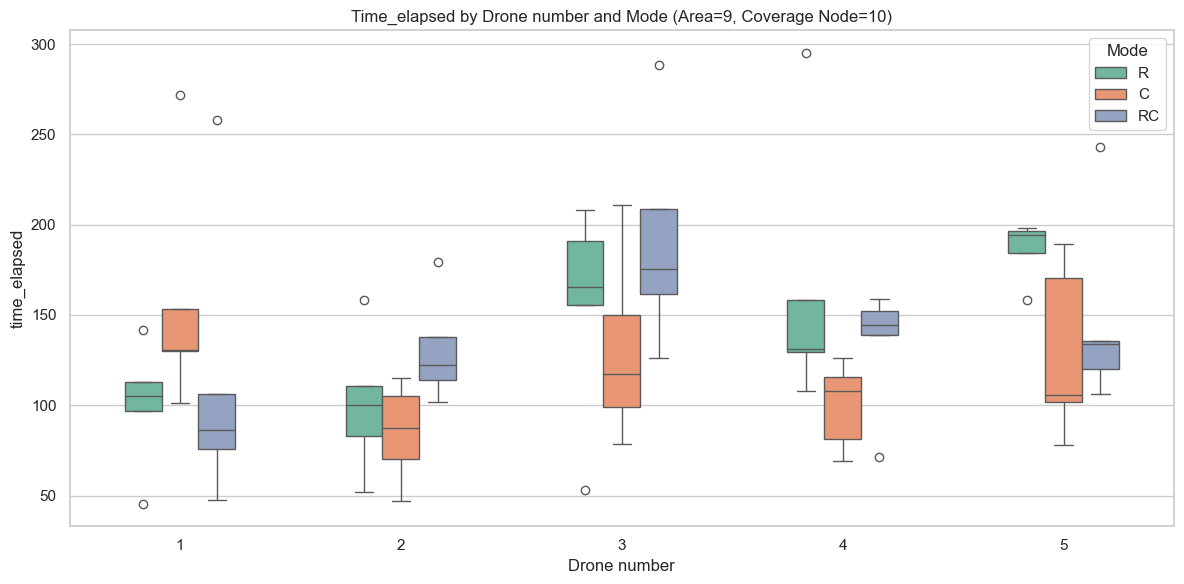

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 样式设置
sns.set(style='whitegrid')

# 假设变量 df 已存在且包含列 ['Mode','Drone_Num','Area','Coverage_Node','global_optimal_time']
# 如果没有，请先运行构造 df 的 cell（你之前已有的那段）

# 复制一份以免破坏原始 df
df_exp = df.copy()

# 如果 global_optimal_time 是列表（每行含多个样本），将其 explode 成多行
if df_exp['time_elapsed'].apply(lambda x: isinstance(x, (list, tuple))).any():
    df_exp = df_exp.explode('time_elapsed')

# 把 time_elapsed 转为数值（若无法转换则变为 NaN）
df_exp['time_elapsed'] = pd.to_numeric(df_exp['time_elapsed'], errors='coerce')

# 筛选出你关心的 Area 和 Coverage_Node（防御性编程）
df_plot = df_exp[(df_exp['Area'] == '9') & (df_exp['Coverage_Node'] == '10')].copy()

# 确保 Drone_Num 有正确顺序（1..5）
df_plot['Drone_Num'] = pd.Categorical(df_plot['Drone_Num'], categories=[1,2,3,4,5], ordered=True)

# 绘图：x=Drone_Num，每个 Drone_Num 下按 Mode 显示三条箱线（R, C, RC）
plt.figure(figsize=(12,6))
ax = sns.boxplot(
    x='Drone_Num',
    y='time_elapsed',
    hue='Mode',
    data=df_plot,
    palette='Set2',
    showfliers=True,
    width=0.5  # 调整箱线图宽度
    )

# 调整 x 轴刻度标签为组号
ax.set_xticks(range(len(df_plot['Drone_Num'].cat.categories)))
ax.set_xticklabels(df_plot['Drone_Num'].cat.categories)
ax.set_xlabel('Drone number')
ax.set_ylabel('time_elapsed')
ax.set_title('Time_elapsed by Drone number and Mode (Area=9, Coverage Node=10)')
plt.legend(title='Mode')
plt.tight_layout()

# 可选：保存图片
# plt.savefig('boxplot_global_optimal_time_A9_C10.png', dpi=300)
# plt.show()

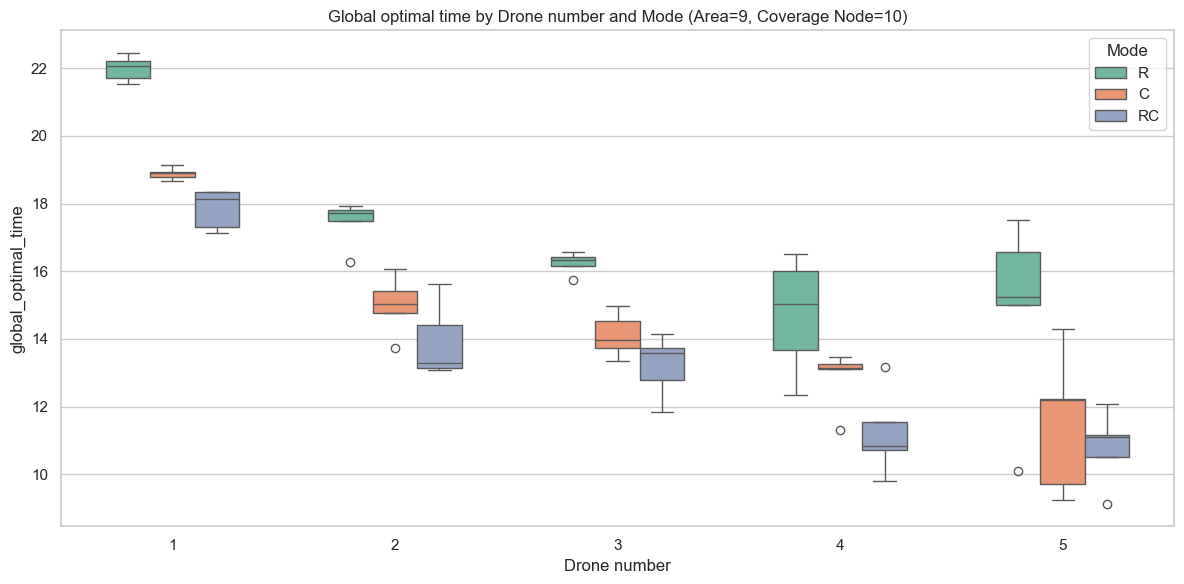

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 样式设置
sns.set(style='whitegrid')

# 假设变量 df 已存在且包含列 ['Mode','Drone_Num','Area','Coverage_Node','global_optimal_time']
# 如果没有，请先运行构造 df 的 cell（你之前已有的那段）

# 复制一份以免破坏原始 df
df_exp = df.copy()

# 如果 global_optimal_time 是列表（每行含多个样本），将其 explode 成多行
if df_exp['global_optimal_time'].apply(lambda x: isinstance(x, (list, tuple))).any():
    df_exp = df_exp.explode('global_optimal_time')

# 把 global_optimal_time 转为数值（若无法转换则变为 NaN）
df_exp['global_optimal_time'] = pd.to_numeric(df_exp['global_optimal_time'], errors='coerce')

# 筛选出你关心的 Area 和 Coverage_Node（防御性编程）
df_plot = df_exp[(df_exp['Area'] == '9') & (df_exp['Coverage_Node'] == '10')].copy()

# 确保 Drone_Num 有正确顺序（1..5）
df_plot['Drone_Num'] = pd.Categorical(df_plot['Drone_Num'], categories=[1,2,3,4,5], ordered=True)

# 绘图：x=Drone_Num，每个 Drone_Num 下按 Mode 显示三条箱线（R, C, RC）
plt.figure(figsize=(12,6))
ax = sns.boxplot(
    x='Drone_Num',
    y='global_optimal_time',
    hue='Mode',
    data=df_plot,
    palette='Set2',
    showfliers=True,
    width=0.6  # 调整箱线图宽度
    )

# 调整 x 轴刻度标签为组号
ax.set_xticks(range(len(df_plot['Drone_Num'].cat.categories)))
ax.set_xticklabels(df_plot['Drone_Num'].cat.categories)
ax.set_xlabel('Drone number')
ax.set_ylabel('global_optimal_time')
ax.set_title('Global optimal time by Drone number and Mode (Area=9, Coverage Node=10)')
plt.legend(title='Mode')
plt.tight_layout()

# 可选：保存图片
# plt.savefig('boxplot_global_optimal_time_A9_C10.png', dpi=300)
# plt.show()

In [78]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

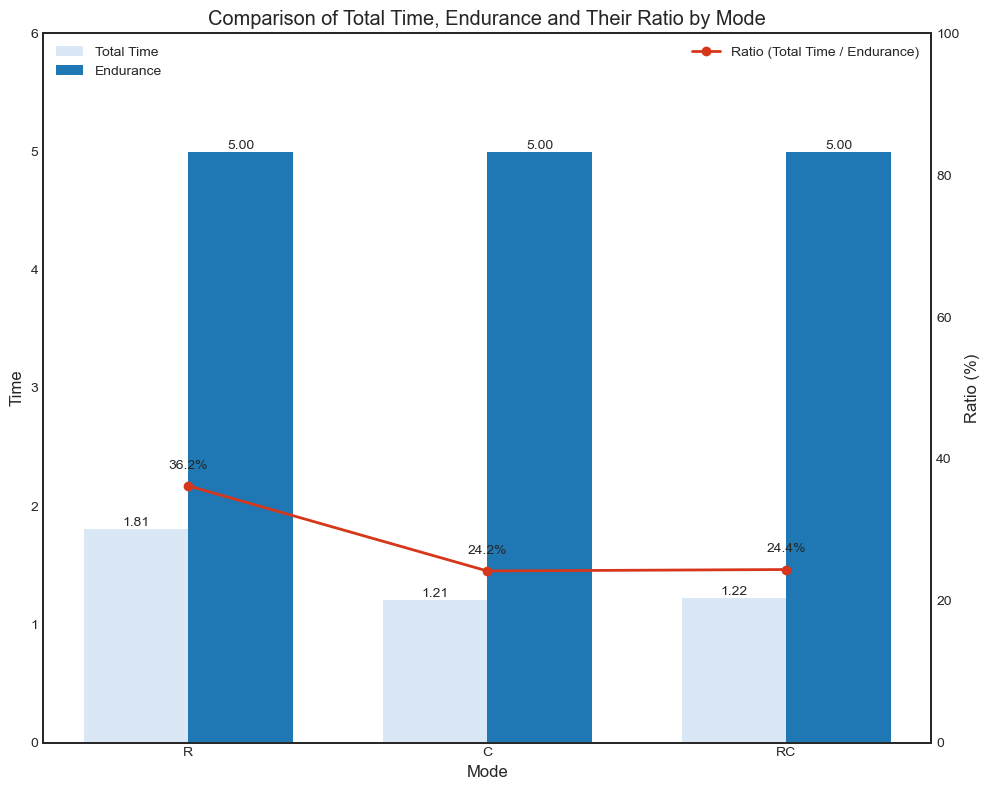

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 设置 seaborn 风格
plt.style.use('seaborn-v0_8-white')

# 模拟 total_time_dict（根据图中数值）
total_time_dict = {'R': 1.81, 'C': 1.21, 'RC': 1.22}
# 无人机的固定 endurance
endurance = 5

# 准备数据
modes = ['R', 'C', 'RC']
total_times = [total_time_dict[mode] for mode in modes]
endurance_values = [endurance] * len(modes)
# 计算 Total Time / Endurance 的比值（转换为百分比）
ratios = [ (tt / endurance) * 100 for tt in total_times ]

# 设置柱状图的宽度和位置
x = np.arange(len(modes))  # x 轴位置
width = 0.35  # 柱状图宽度

# 绘制图表（创建双Y轴）
fig, ax1 = plt.subplots(figsize=(10, 8))  # 先增大图的高度，让Y轴更舒展

# 左侧Y轴：绘制柱状图（Total Time 和 Endurance）
bar1 = ax1.bar(x - width/2, total_times, width, label='Total Time', color="#1e7cbe2b")
bar2 = ax1.bar(x + width/2, endurance_values, width, label='Endurance', color='#1f77b4')

# 左侧Y轴设置：增大刻度范围（比如从0到8，原先是0到5）
ax1.set_xlabel('Mode')
ax1.set_ylabel('Time')
ax1.set_title('Comparison of Total Time, Endurance and Their Ratio by Mode')
ax1.set_xticks(x)
ax1.set_xticklabels(modes)
ax1.set_ylim(0, 6)  # 关键：调整左侧Y轴范围（从0到8，可根据需求修改）
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')

# 右侧Y轴：绘制比值折线（Total Time / Endurance，单位%）
ax2 = ax1.twinx()
line = ax2.plot(x, ratios, color="#d6371b", marker='o', linestyle='-', linewidth=2, label='Ratio (Total Time / Endurance)')

# 右侧Y轴设置：同步增大刻度范围（比如从0到40，原先是0到36）
ax2.set_ylabel('Ratio (%)')
ax2.set_ylim(0, 100)  # 关键：调整右侧Y轴范围（与左侧比例匹配）
ax2.tick_params(axis='y')
ax2.legend(loc='upper right')

# 显示柱状图数值标签
for bar in bar1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=10)
for bar in bar2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom', fontsize=10)

# 显示折线图数值标签
for i, ratio in enumerate(ratios):
    ax2.text(x[i], ratio + 2, f'{ratio:.1f}%', ha='center', va='bottom', fontsize=10)

# 调整布局并显示图表
plt.tight_layout()
plt.show()